In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
from sklearn.metrics import matthews_corrcoef, make_scorer

IMPORTING DATASETS

In [2]:
data_log2 = pd.read_pickle('data_log2_Lisbon_threshold.pkl')

In [3]:
data_log2 

Protein.Group,A0A0A0MS15,A0A0C4DH38,O00391,O00462,O00533,O14498,O14594,O14773,O15031,O15394,...,Q9UBP4,Q9UBX1,Q9UBX5,Q9UGM5,Q9UHL4,Q9ULB1,Q9Y240,Q9Y4C0,Q9Y646,Q9Y6R7
LIS090,8.008485,7.884580,7.046524,4.877352,9.502615,6.808836,6.264486,6.706240,5.754602,8.666203,...,11.983824,7.474387,7.673846,6.288357,6.569209,8.519585,4.462792,8.721916,6.428503,9.765251
LIS098,8.408618,8.316675,6.742249,5.249123,9.214086,6.607503,5.651112,6.832662,6.195058,8.234889,...,11.609941,7.249929,7.780402,6.187722,6.248402,8.200359,4.626223,8.767165,6.877487,8.354624
LIS017,6.710379,7.121647,6.803782,5.281576,9.288289,6.816740,6.544420,6.978630,6.114546,8.426206,...,11.674201,7.640505,8.166806,5.968895,6.599523,8.233011,5.536920,8.527669,7.343052,7.835937
LIS026,8.605772,8.765760,7.234664,4.971061,9.194671,6.489169,6.035030,6.804389,5.470348,8.621330,...,11.564264,7.439665,8.143383,7.001780,6.322777,8.011177,4.982035,8.391046,6.702228,8.845537
LIS009,8.695162,8.731662,7.343248,4.763098,9.380682,6.913033,6.115934,6.661621,5.664136,8.492606,...,11.567961,7.399504,7.611748,7.179829,6.603539,7.870790,4.998123,8.460526,6.401837,9.694913
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LIS096,8.944671,8.747877,6.899816,5.284466,9.197529,6.396685,7.142434,6.582059,5.887986,8.347488,...,11.364140,6.734005,7.813114,5.887223,6.989116,8.596130,4.606496,8.836341,6.434588,9.504585
LIS097,8.581528,7.769580,7.149879,4.566925,9.078714,7.260854,6.789195,5.965960,5.749282,7.980528,...,11.345755,7.420508,8.007846,6.271569,6.409046,8.521522,4.588019,8.792074,6.873395,9.545036
LIS102,8.583207,7.473089,7.144108,4.763582,9.710235,7.141964,7.286142,6.577400,5.992549,8.624346,...,11.306529,7.106997,7.976610,6.025791,6.078200,8.961421,4.840297,9.106806,6.697260,9.566731
LIS103,8.504410,9.427137,6.745062,4.590740,8.539744,7.318733,5.619750,6.116679,5.785435,8.008053,...,10.799476,7.207493,7.716394,6.032231,5.496488,8.011059,4.539847,8.241826,6.325904,10.136773


In [4]:
import pickle

with open('list_groups.pkl', 'rb') as f:
    list_groups = pickle.load(f)

print(list_groups)

['MCI-AD', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-AD', 'MCI-AD', 'MCI-AD', 'MCI-AD', 'MCI-AD', 'MCI-AD', 'MCI-AD', 'MCI-AD', 'MCI-AD', 'MCI-AD', 'MCI-AD', 'MCI-AD', 'MCI-AD', 'MCI-AD', 'MCI-AD', 'MCI-AD', 'MCI-AD', 'MCI-AD', 'MCI-AD', 'MCI-AD', 'MCI-AD', 'MCI-AD', 'MCI-AD', 'MCI-AD', 'MCI-AD', 'MCI-AD', 'MCI-AD', 'MCI-AD', 'MCI-AD', 'MCI-AD', 'MCI-AD', 'MCI-AD', 'MCI-AD', 'MCI-AD', 'MCI-AD', 'MCI-AD', 'MCI-AD', 'MCI-AD', 'MCI-AD', 'MCI-AD', 'MCI-AD']


In [5]:
list_groups = pd.Series(list_groups)

APPLYING SIMPLE RANDOM FOREST

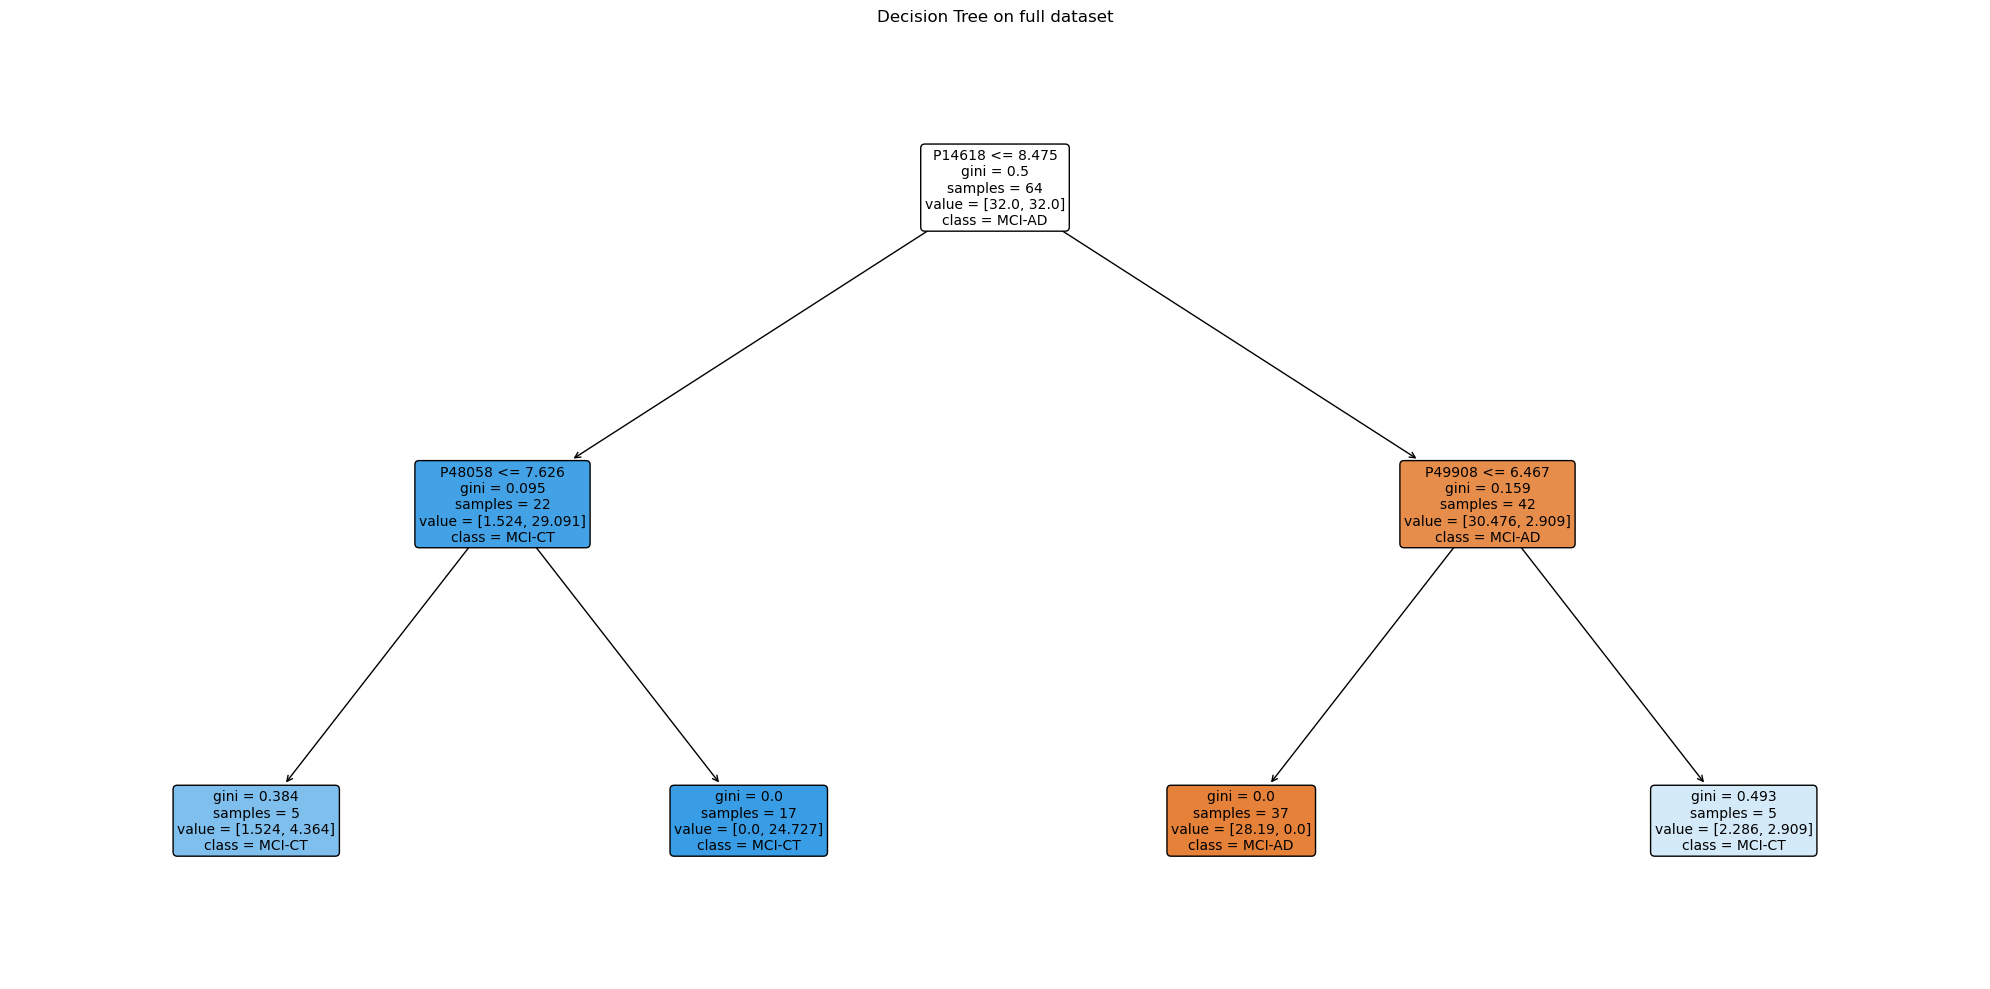


Decision Rules:

|--- P14618 <= 8.47
|   |--- P48058 <= 7.63
|   |   |--- class: MCI-CT
|   |--- P48058 >  7.63
|   |   |--- class: MCI-CT
|--- P14618 >  8.47
|   |--- P49908 <= 6.47
|   |   |--- class: MCI-AD
|   |--- P49908 >  6.47
|   |   |--- class: MCI-CT



In [6]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

# ======================
# DATA
# ======================
X = data_log2.copy()
y = np.array(list_groups)

# ======================
# MODELLO SEMPLICE
# ======================
dt = DecisionTreeClassifier(
    max_depth=3,          # fondamentale per leggibilità
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=0
)

dt.fit(X, y)

# ======================
# PLOT ALBERO
# ======================
plt.figure(figsize=(20, 10))
plot_tree(
    dt,
    feature_names=X.columns,
    class_names=dt.classes_,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree on full dataset")
plt.tight_layout()
plt.savefig("simple_tree_Lisbon.png", dpi=300, bbox_inches='tight')
plt.show()

# ======================
# REGOLE TESTUALI
# ======================
print("\nDecision Rules:\n")
rules = export_text(dt, feature_names=list(X.columns))
print(rules)

RANDOM FOREST 

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import matthews_corrcoef, roc_auc_score

# ======================
# DATI
# ======================
X = data_log2.copy()
y = np.array(list_groups)

# binarizza per AUC (importante!)
y_binary = (y == "MCI-AD").astype(int)

# ======================
# PARAMETRI GLOBALI
# ======================
thresholds = [ 0.7, 0.8, 0.9]
n_iterations = 20
seeds = range(15)

# ======================
# STORAGE
# ======================
all_results = []
feature_counter = {}
threshold_counter = {}

# ======================
# BOOTSTRAP
# ======================
def stratified_bootstrap(X, y):
    ad_idx = np.where(y == "MCI-AD")[0]
    ct_idx = np.where(y == "MCI-CT")[0]

    ad_sample = np.random.choice(ad_idx, size=len(ad_idx), replace=True)
    ct_sample = np.random.choice(ct_idx, size=len(ct_idx), replace=True)

    indices = np.concatenate([ad_sample, ct_sample])
    np.random.shuffle(indices)

    return X.iloc[indices], y[indices]


# ======================
# LOOP SEED
# ======================
for seed in seeds:

    print(f"\n===== SEED {seed} =====")

    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        stratify=y,
        random_state=seed
    )

    y_train_bin = (y_train == "MCI-AD").astype(int)
    y_test_bin = (y_test == "MCI-AD").astype(int)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    threshold_scores = []

    # ======================
    # CV per scegliere threshold
    # ======================
    for t in thresholds:

        fold_scores = []

        for train_idx, val_idx in cv.split(X_train, y_train):

            X_subtrain = X_train.iloc[train_idx]
            y_subtrain = y_train[train_idx]

            X_val = X_train.iloc[val_idx]
            y_val = y_train[val_idx]

            y_val_bin = (y_val == "MCI-AD").astype(int)

            # ===== bootstrap importance
            feature_names = X_subtrain.columns
            importance_matrix = np.zeros((n_iterations, len(feature_names)))

            for i in range(n_iterations):

                X_boot, y_boot = stratified_bootstrap(X_subtrain, y_subtrain)

                rf = RandomForestClassifier(
                    n_estimators=200,
                    class_weight="balanced",
                    n_jobs=-1,
                    random_state=seed
                )

                rf.fit(X_boot, y_boot)
                importance_matrix[i] = rf.feature_importances_

            mean_importance = importance_matrix.mean(axis=0)

            ranking_df = pd.DataFrame({
                "protein": feature_names,
                "importance": mean_importance
            }).sort_values("importance", ascending=False)

            # normalizzazione
            ranking_df["importance"] /= ranking_df["importance"].sum()
            ranking_df["cum_importance"] = ranking_df["importance"].cumsum()

            # selezione feature
            selected_features = ranking_df[
                ranking_df["cum_importance"] <= t
            ]["protein"]

            if len(selected_features) == 0:
                selected_features = ranking_df["protein"].iloc[:1]

            # train modello
            rf = RandomForestClassifier(
                n_estimators=200,
                class_weight="balanced",
                random_state=seed
            )

            rf.fit(X_subtrain[selected_features], y_subtrain)

            # valutazione
            y_pred = rf.predict(X_val[selected_features])
            mcc = matthews_corrcoef(y_val, y_pred)

            fold_scores.append(mcc)

        threshold_scores.append(np.mean(fold_scores))

    # ======================
    # best threshold
    # ======================
    best_threshold = thresholds[np.argmax(threshold_scores)]
    print("Best threshold:", best_threshold)

    # ======================
    # TRAIN FINALE (su tutto train)
    # ======================
    feature_names = X_train.columns
    importance_matrix = np.zeros((n_iterations, len(feature_names)))

    for i in range(n_iterations):

        X_boot, y_boot = stratified_bootstrap(X_train, y_train)

        rf = RandomForestClassifier(
            n_estimators=500,
            class_weight="balanced",
            n_jobs=-1,
            random_state=i
        )

        rf.fit(X_boot, y_boot)
        importance_matrix[i] = rf.feature_importances_

    mean_importance = importance_matrix.mean(axis=0)

    ranking_df = pd.DataFrame({
        "protein": feature_names,
        "importance": mean_importance
    }).sort_values("importance", ascending=False)

    ranking_df["importance"] /= ranking_df["importance"].sum()
    ranking_df["cum_importance"] = ranking_df["importance"].cumsum()

    top_features = ranking_df[
        ranking_df["cum_importance"] <= best_threshold
    ]["protein"]

    if len(top_features) == 0:
        top_features = ranking_df["protein"].iloc[:1]

    print("Numero feature:", len(top_features))

    # ======================
    # TEST
    # ======================
    rf_final = RandomForestClassifier(
        n_estimators=500,
        class_weight="balanced",
        random_state=42
    )

    rf_final.fit(X_train[top_features], y_train)

    y_pred = rf_final.predict(X_test[top_features])
    class_order = rf_final.classes_
    ad_index = np.where(class_order == "MCI-AD")[0][0]
    
    y_prob = rf_final.predict_proba(X_test[top_features])[:, ad_index]

    test_mcc = matthews_corrcoef(y_test, y_pred)
    test_auc = roc_auc_score(y_test_bin, y_prob)
    print("Class order:", rf_final.classes_)
    print("Test MCC:", test_mcc)
    print("Test AUC:", test_auc)

    # ======================
    # SALVATAGGIO
    # ======================
    all_results.append({
        "model": "RF",
        "seed": seed,
        "mcc": test_mcc,
        "auc": test_auc,
        "n_features": len(top_features),
        "best_threshold": best_threshold
    })

    # frequenza feature
    for f in top_features:
        feature_counter[f] = feature_counter.get(f, 0) + 1

    # frequenza threshold
    threshold_counter[best_threshold] = threshold_counter.get(best_threshold, 0) + 1


# ======================
# RISULTATI FINALI
# ======================
df_results = pd.DataFrame(all_results)

print("\n===== FINAL RESULTS =====")
print("Mean MCC:", df_results["mcc"].mean())
print("Mean AUC:", df_results["auc"].mean())

# frequenze
feature_freq = pd.Series(feature_counter).sort_values(ascending=False) / len(seeds)
threshold_freq = pd.Series(threshold_counter).sort_index() / len(seeds)

print("\nTop features (frequency):")
print(feature_freq.head(20))

print("\nThreshold frequency:")
print(threshold_freq)


===== SEED 0 =====
Best threshold: 0.7
Numero feature: 55
Class order: ['MCI-AD' 'MCI-CT']
Test MCC: 0.6388888888888888
Test AUC: 0.9166666666666666

===== SEED 1 =====
Best threshold: 0.7
Numero feature: 63
Class order: ['MCI-AD' 'MCI-CT']
Test MCC: 0.8432740427115678
Test AUC: 0.8888888888888888

===== SEED 2 =====
Best threshold: 0.7
Numero feature: 71
Class order: ['MCI-AD' 'MCI-CT']
Test MCC: 1.0
Test AUC: 1.0

===== SEED 3 =====
Best threshold: 0.7
Numero feature: 57
Class order: ['MCI-AD' 'MCI-CT']
Test MCC: 0.6388888888888888
Test AUC: 0.9166666666666666

===== SEED 4 =====
Best threshold: 0.8
Numero feature: 94
Class order: ['MCI-AD' 'MCI-CT']
Test MCC: 0.6388888888888888
Test AUC: 0.9166666666666666

===== SEED 5 =====
Best threshold: 0.9
Numero feature: 154
Class order: ['MCI-AD' 'MCI-CT']
Test MCC: 0.8215838362577492
Test AUC: 1.0

===== SEED 6 =====
Best threshold: 0.8
Numero feature: 109
Class order: ['MCI-AD' 'MCI-CT']
Test MCC: 1.0
Test AUC: 1.0

===== SEED 7 =====
Bes

In [8]:
feature_freq.to_pickle('feature_rf_Lisbon_threshold.pkl')
df_results = pd.DataFrame(all_results)
df_results.to_pickle('results_Lisbon_rf_threshold.pkl')

In [9]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import matthews_corrcoef, roc_auc_score

# ======================
# DATI
# ======================
X = data_log2.copy()
y = np.array(list_groups)
y_binary = (y == "MCI-AD").astype(int)

# ======================
# PARAMETRI
# ======================
thresholds = [0.7, 0.8, 0.9]
n_iterations = 20
n_splits = 5

# ======================
# BOOTSTRAP
# ======================
def stratified_bootstrap(X, y):
    ad_idx = np.where(y == "MCI-AD")[0]
    ct_idx = np.where(y == "MCI-CT")[0]

    ad_sample = np.random.choice(ad_idx, size=len(ad_idx), replace=True)
    ct_sample = np.random.choice(ct_idx, size=len(ct_idx), replace=True)

    indices = np.concatenate([ad_sample, ct_sample])
    np.random.shuffle(indices)

    return X.iloc[indices], y[indices]

# ======================
# CV
# ======================
cv = StratifiedShuffleSplit(n_splits=n_splits, test_size=0.3, random_state=42)

threshold_scores = []

# ======================
# SCELTA THRESHOLD (CV)
# ======================
for t in thresholds:

    fold_mcc = []
    fold_auc = []

    for train_idx, val_idx in cv.split(X, y):

        X_sub = X.iloc[train_idx]
        y_sub = y[train_idx]

        X_val = X.iloc[val_idx]
        y_val = y[val_idx]
        y_val_bin = (y_val == "MCI-AD").astype(int)

        # ===== bootstrap importance
        feature_names = X_sub.columns
        importance_matrix = np.zeros((n_iterations, len(feature_names)))

        for i in range(n_iterations):
            X_boot, y_boot = stratified_bootstrap(X_sub, y_sub)

            rf = RandomForestClassifier(
                n_estimators=200,
                class_weight="balanced",
                n_jobs=-1,
                random_state=i
            )

            rf.fit(X_boot, y_boot)
            importance_matrix[i] = rf.feature_importances_

        mean_importance = importance_matrix.mean(axis=0)

        ranking_df = pd.DataFrame({
            "protein": feature_names,
            "importance": mean_importance
        }).sort_values("importance", ascending=False)

        ranking_df["importance"] /= ranking_df["importance"].sum()
        ranking_df["cum_importance"] = ranking_df["importance"].cumsum()

        selected_features = ranking_df[
            ranking_df["cum_importance"] <= t
        ]["protein"]

        if len(selected_features) == 0:
            selected_features = ranking_df["protein"].iloc[:1]

        # modello
        rf_model = RandomForestClassifier(
            n_estimators=200,
            class_weight="balanced",
            random_state=42
        )

        rf_model.fit(X_sub[selected_features], y_sub)

        y_pred = rf_model.predict(X_val[selected_features])

        # ✅ FIX AUC
        class_order = rf_model.classes_
        ad_index = np.where(class_order == "MCI-AD")[0][0]
        y_prob = rf_model.predict_proba(X_val[selected_features])[:, ad_index]

        fold_mcc.append(matthews_corrcoef(y_val, y_pred))
        fold_auc.append(roc_auc_score(y_val_bin, y_prob))

    threshold_scores.append(np.mean(fold_mcc))

# ======================
# BEST THRESHOLD
# ======================
best_threshold = thresholds[np.argmax(threshold_scores)]
print("Best threshold:", best_threshold)

# ======================
# PERFORMANCE FINALE (CV)
# ======================
all_mcc = []
all_auc = []

# ✅ FREQUENZA FEATURE
feature_counts = pd.Series(0, index=X.columns)

for train_idx, val_idx in cv.split(X, y):

    X_sub = X.iloc[train_idx]
    y_sub = y[train_idx]

    X_val = X.iloc[val_idx]
    y_val = y[val_idx]
    y_val_bin = (y_val == "MCI-AD").astype(int)

    # bootstrap importance
    importance_matrix = np.zeros((n_iterations, X.shape[1]))

    for i in range(n_iterations):
        X_boot, y_boot = stratified_bootstrap(X_sub, y_sub)

        rf = RandomForestClassifier(
            n_estimators=200,
            class_weight="balanced",
            n_jobs=-1,
            random_state=i
        )

        rf.fit(X_boot, y_boot)
        importance_matrix[i] = rf.feature_importances_

    mean_importance = importance_matrix.mean(axis=0)

    ranking_df = pd.DataFrame({
        "protein": X.columns,
        "importance": mean_importance
    }).sort_values("importance", ascending=False)

    ranking_df["importance"] /= ranking_df["importance"].sum()
    ranking_df["cum_importance"] = ranking_df["importance"].cumsum()

    selected_features = ranking_df[
        ranking_df["cum_importance"] <= best_threshold
    ]["protein"]

    if len(selected_features) == 0:
        selected_features = ranking_df["protein"].iloc[:1]

    # ✅ conteggio frequenza
    feature_counts[selected_features] += 1

    rf_model = RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42
    )

    rf_model.fit(X_sub[selected_features], y_sub)

    y_pred = rf_model.predict(X_val[selected_features])

    # ✅ FIX AUC
    class_order = rf_model.classes_
    ad_index = np.where(class_order == "MCI-AD")[0][0]
    y_prob = rf_model.predict_proba(X_val[selected_features])[:, ad_index]

    all_mcc.append(matthews_corrcoef(y_val, y_pred))
    all_auc.append(roc_auc_score(y_val_bin, y_prob))

# ======================
# METRICHE FINALI
# ======================
print("\n=== VALIDATION PERFORMANCE ===")
print(f"MCC: {np.mean(all_mcc):.4f} ± {np.std(all_mcc):.4f}")
print(f"AUC: {np.mean(all_auc):.4f} ± {np.std(all_auc):.4f}")

# ======================
# FREQUENZA FEATURE
# ======================
feature_freq = (feature_counts / n_splits).sort_values(ascending=False)

print("\n=== FEATURE SELECTION FREQUENCY ===")
print(feature_freq)

# ======================
# FEATURE IMPORTANCE FINALE
# ======================
importance_matrix = np.zeros((n_iterations, X.shape[1]))

for i in range(n_iterations):
    X_boot, y_boot = stratified_bootstrap(X, y)

    rf = RandomForestClassifier(
        n_estimators=500,
        class_weight="balanced",
        n_jobs=-1,
        random_state=i
    )

    rf.fit(X_boot, y_boot)
    importance_matrix[i] = rf.feature_importances_

mean_importance = importance_matrix.mean(axis=0)

ranking_df = pd.DataFrame({
    "protein": X.columns,
    "importance": mean_importance
}).sort_values("importance", ascending=False)

ranking_df["importance"] /= ranking_df["importance"].sum()
ranking_df["cum_importance"] = ranking_df["importance"].cumsum()

print("\n=== GLOBAL RF RANKING ===")
print(ranking_df)

# salva
ranking_df.to_csv("rf_global_ranking.csv", index=False)
feature_freq.to_csv("rf_feature_frequency.csv")

Best threshold: 0.8

=== VALIDATION PERFORMANCE ===
MCC: 0.7577 ± 0.1287
AUC: 0.9582 ± 0.0463

=== FEATURE SELECTION FREQUENCY ===
Protein.Group
P07195    1.0
Q9NTU7    1.0
P07333    1.0
Q13740    1.0
P06733    1.0
         ... 
P08253    0.0
P08174    0.0
P07998    0.0
P07339    0.0
Q9Y6R7    0.0
Length: 255, dtype: float64

=== GLOBAL RF RANKING ===
    protein  importance  cum_importance
133  P14618    0.062239        0.062239
191  Q13449    0.046288        0.108527
164  P40925    0.046083        0.154610
238  Q9NQ79    0.035881        0.190491
96   P07195    0.022729        0.213220
..      ...         ...             ...
142  P19823    0.000643        0.997750
84   P05090    0.000631        0.998381
189  Q13228    0.000570        0.998951
71   P04004    0.000534        0.999485
135  P16070    0.000515        1.000000

[255 rows x 3 columns]


In [10]:
feature_freq.to_pickle('feature_2_rf_Lisbon_threshold.pkl')